<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%204/L3_Backpropagation_in_CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=pp6LPJuw0Po) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%204/NPTEL_Jul24_DL4CV_W04_P02.pdf)

In [ ]:
# Week 4, Lecture 3: Backprop in CNN's
from IPython.display import HTML, display

VIDEO_ID = "pp6LPJuw0Po"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

Watch on YouTube

# Week 4, Lecture 3: Backpropagation in CNNs

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§4.2 Backpropagation in CNNs**.

We derive, and then verify, the gradients that flow backward through a
convolution layer and a pooling layer.

**What you will learn**

Each item is built from scratch first with explicit loops, then checked against
`torch.autograd`:
- Forward convolution from the slide formula, matched to `F.conv2d`.
- The two gradients a conv layer needs, assuming the upstream gradient
  $\partial L/\partial Y$ is known:
  - $\partial L/\partial W$, to update the filter,
  - $\partial L/\partial X$, to pass back to the previous layer.
- Pooling backprop: how max pooling and average pooling route gradients.

Assumptions (from the slides): a single grayscale channel $C=1$ and a single
filter (one output channel).

A note on convention. The slide writes convolution with a filter flip,
$Y[i,j]=\sum_{a,b} X[i-a,\,j-b]\,W[a,b]$ (the filter placed at a corner). Like
PyTorch, we implement the equivalent **cross-correlation**
$Y[i,j]=\sum_{a,b} X[i+a,\,j+b]\,W[a,b]$ (filter at the top-left corner, no
flip). It is the same operation up to flipping $W$, and it makes `F.conv2d`
match our code exactly. The lecture punchline, that the input gradient uses a
flipped filter, still appears clearly.

Prerequisites: basic Python, numpy, and intro neural networks.

**How to run**  On Colab the widgets work automatically; just run the cells top
to bottom.

**Contents**

1. Forward convolution
2. Who is connected to whom?
3. The two gradients
4. Weight gradient $\partial L/\partial W$
5. Input gradient $\partial L/\partial X$
6. Backprop through pooling
7. Capstone: one full backward pass end to end

## Review

The previous lecture motivated CNNs through local receptive fields, weight sharing and pooling, and surveyed the convolution variants. All of that was the forward pass. This lecture sends the gradient back through it.

## Setup

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown

# Reproducibility and device (works on both CPU and GPU Colab runtimes).
torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("PyTorch version:", torch.__version__)
print("Device:", device)

def flip180(w):
    # Rotate a 2D kernel by 180 degrees (flip both spatial axes).
    return torch.flip(w, dims=[-2, -1])

def show_grid(ax, M, title="", cmap="Blues", highlight=None, fmt="{:.0f}"):
    # Draw a 2D tensor as an annotated heatmap. Each cell shows its value.
    # highlight: an iterable of (row, col) to outline in red.
    M = M.detach().cpu().numpy()
    ax.imshow(M, cmap=cmap)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(M.shape[1]))
    ax.set_yticks(range(M.shape[0]))
    mn, mx = float(M.min()), float(M.max())
    rng = (mx - mn) if mx > mn else 1.0
    for r in range(M.shape[0]):
        for c in range(M.shape[1]):
            t = (M[r, c] - mn) / rng            # pick text color for contrast
            col = "white" if t > 0.6 else "black"
            ax.text(c, r, fmt.format(M[r, c]), ha="center", va="center",
                    color=col, fontsize=9)
    if highlight:
        for (r, c) in highlight:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False,
                                       edgecolor="red", lw=2.5))
print("setup ready")

PyTorch version: 2.8.0
Device: cpu
setup ready


## 1. Forward convolution

A single filter $W$ of size $K_1\times K_2$ slides over the input $X$ of size
$N_1\times N_2$ and produces $Y$ of size $M_1\times M_2$ with
$$M_1=N_1-K_1+1,\qquad M_2=N_2-K_2+1,$$
which is the familiar $W_2=\frac{W_1-F+2P}{S}+1$ with stride $S=1$ and padding
$P=0$. (Exercise from the slides: a $32\times 32\times 3$ image with six
$5\times 5\times 3$ filters gives a $28\times 28\times 6$ output volume.)

Our cross-correlation forward rule:
$$Y[i,j]=\sum_{a=0}^{K_1-1}\sum_{b=0}^{K_2-1} X[i+a,\,j+b]\,W[a,b].$$

Below we compute $Y$ with explicit loops and check it against `F.conv2d`.

In [2]:
# Small integer-friendly tensors so the arithmetic is easy to follow.
X = torch.tensor([[3., 0., 1., 2., 7.],
                  [1., 5., 8., 9., 3.],
                  [2., 7., 2., 5., 1.],
                  [0., 1., 3., 1., 7.],
                  [4., 2., 1., 6., 2.]])
W = torch.tensor([[1., 0., -1.],
                  [1., 0., -1.],
                  [1., 0., -1.]])      # a vertical-edge (Sobel-like) filter

N1, N2 = X.shape
K1, K2 = W.shape
M1, M2 = N1 - K1 + 1, N2 - K2 + 1

def conv2d_scratch(X, W):
    # Y[i,j] = sum_{a,b} X[i+a, j+b] * W[a,b]   (cross-correlation, valid mode)
    N1, N2 = X.shape
    K1, K2 = W.shape
    M1, M2 = N1 - K1 + 1, N2 - K2 + 1
    Y = torch.zeros(M1, M2)
    for i in range(M1):
        for j in range(M2):
            s = 0.0
            for a in range(K1):
                for b in range(K2):
                    s += X[i + a, j + b] * W[a, b]
            Y[i, j] = s
    return Y

Y = conv2d_scratch(X, W)
print("X shape:", tuple(X.shape), " W shape:", tuple(W.shape),
      " Y shape:", tuple(Y.shape))
print("Y (from scratch):\n", Y)

# F.conv2d computes cross-correlation, so it must match our loops exactly.
Y_torch = F.conv2d(X[None, None], W[None, None])[0, 0]
print("Y (F.conv2d):\n", Y_torch)
assert torch.allclose(Y, Y_torch), "scratch forward must match F.conv2d"
print("OK: scratch forward matches F.conv2d")

X shape: (5, 5)  W shape: (3, 3)  Y shape: (3, 3)
Y (from scratch):
 tensor([[ -5.,  -4.,   0.],
        [-10.,  -2.,   2.],
        [  0.,  -2.,  -4.]])
Y (F.conv2d):
 tensor([[ -5.,  -4.,   0.],
        [-10.,  -2.,   2.],
        [  0.,  -2.,  -4.]])
OK: scratch forward matches F.conv2d


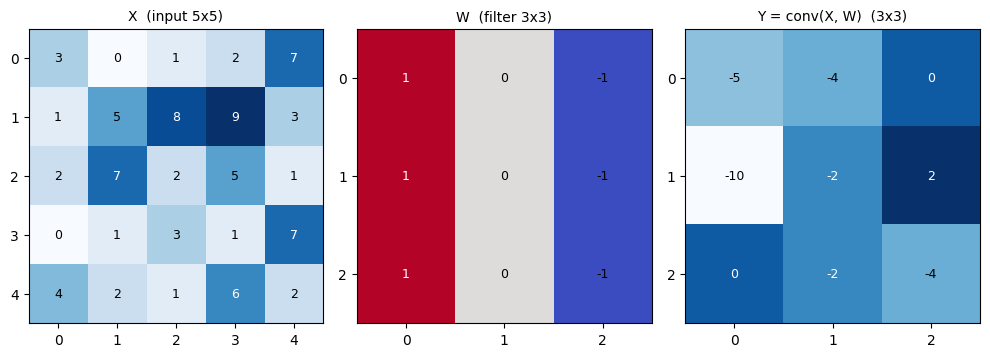

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
show_grid(axes[0], X, "X  (input 5x5)", cmap="Blues")
show_grid(axes[1], W, "W  (filter 3x3)", cmap="coolwarm")
show_grid(axes[2], Y, "Y = conv(X, W)  (3x3)", cmap="Blues")
plt.tight_layout(); plt.show()

## 2. Who is connected to whom?

Two facts drive the whole derivation:
- A single WEIGHT $W[a,b]$ helps compute EVERY output pixel (each output is a
  weighted sum that always uses every weight). So its gradient will sum
  contributions from all of $Y$.
- A single input pixel $X[i',j']$ only affects a small region $P$ of outputs
  (the outputs whose sliding window covers it). So its gradient sums only over
  that region $P$.

Use the widget to see the region $P$ for a chosen input pixel, and to confirm
that a chosen weight lights up the whole output.

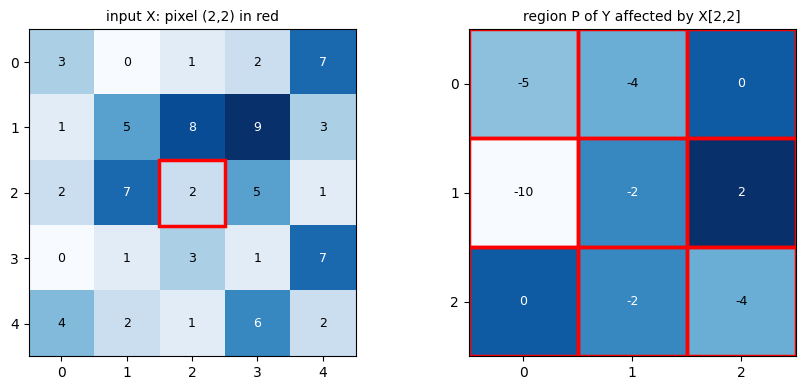

In [4]:
def outputs_for_input(p, q):
    # Which output pixels (i,j) does input X[p,q] feed?  i+a=p, j+b=q with
    # a in [0,K1-1], b in [0,K2-1]  =>  i in [p-K1+1, p], j in [q-K2+1, q].
    rows = range(max(0, p - K1 + 1), min(M1 - 1, p) + 1)
    cols = range(max(0, q - K2 + 1), min(M2 - 1, q) + 1)
    return [(i, j) for i in rows for j in cols]

# Static example: input pixel (2,2) and its region P, next to weight (0,0).
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
show_grid(axes[0], X, "input X: pixel (2,2) in red", highlight={(2, 2)})
show_grid(axes[1], Y, "region P of Y affected by X[2,2]",
          highlight=set(outputs_for_input(2, 2)))
plt.tight_layout(); plt.show()

In [5]:
# WIDGET 1: connectivity explorer.
def show_connectivity(mode="input pixel -> region P", pi=2, pj=2, wa=0, wb=0):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    if mode.startswith("input"):
        show_grid(axes[0], X, "input X: pixel (%d,%d)" % (pi, pj),
                  highlight={(pi, pj)})
        P = outputs_for_input(pi, pj)
        show_grid(axes[1], Y, "outputs affected (region P), %d pixel(s)" % len(P),
                  highlight=set(P))
    else:
        show_grid(axes[0], W, "filter W: weight (%d,%d)" % (wa, wb),
                  cmap="coolwarm", highlight={(wa, wb)})
        allout = {(i, j) for i in range(M1) for j in range(M2)}
        show_grid(axes[1], Y, "weight W[%d,%d] affects EVERY output" % (wa, wb),
                  highlight=allout)
    plt.tight_layout(); plt.show()

interact(show_connectivity,
         mode=Dropdown(options=["input pixel -> region P",
                                "weight -> all outputs"],
                       value="input pixel -> region P"),
         pi=IntSlider(min=0, max=N1 - 1, value=2, description="i' row"),
         pj=IntSlider(min=0, max=N2 - 1, value=2, description="j' col"),
         wa=IntSlider(min=0, max=K1 - 1, value=0, description="a w-row"),
         wb=IntSlider(min=0, max=K2 - 1, value=0, description="b w-col"));

interactive(children=(Dropdown(description='mode', options=('input pixel -> region P', 'weight -> all outputs'…

## 3. The two gradients

We assume the upstream gradient $\partial L/\partial Y$ is already known (it
arrives from the layers above during backprop). From it we compute:
1. $\partial L/\partial W$, to update the filter,
2. $\partial L/\partial X$, to keep backprop going to earlier layers.

For every derivation below we make up an upstream $\partial L/\partial Y$,
implement the formula from scratch, and assert it equals `torch.autograd`.

## 4. Weight gradient $\partial L/\partial W$

Because $W[a,b]$ touches every output, sum the chain rule over all of $Y$:
$$\frac{\partial L}{\partial W[a,b]}=\sum_{i}\sum_{j}
  \frac{\partial L}{\partial Y[i,j]}\,\frac{\partial Y[i,j]}{\partial W[a,b]}.$$
From the forward rule, $\dfrac{\partial Y[i,j]}{\partial W[a,b]}=X[i+a,\,j+b]$,
so
$$\frac{\partial L}{\partial W[a,b]}=\sum_{i}\sum_{j}
  \frac{\partial L}{\partial Y[i,j]}\,X[i+a,\,j+b].$$
This is itself a convolution of the input with the upstream gradient. In code
$\partial L/\partial W=\texttt{conv2d}(X,\ \partial L/\partial Y)$ (the slide
writes it $X * \partial L/\partial Y$). We verify against autograd.

In [6]:
# Make up an upstream gradient dL/dY of the same shape as Y. A varied ramp
# 1..9 is a stronger test than all-ones (it is not symmetric).
dY = torch.arange(1., M1 * M2 + 1.).reshape(M1, M2)
print("upstream dL/dY:\n", dY)

# From scratch: dW[a,b] = sum_{i,j} dY[i,j] * X[i+a, j+b]
def dW_scratch(X, dY, K1, K2):
    dW = torch.zeros(K1, K2)
    M1, M2 = dY.shape
    for a in range(K1):
        for b in range(K2):
            s = 0.0
            for i in range(M1):
                for j in range(M2):
                    s += dY[i, j] * X[i + a, j + b]
            dW[a, b] = s
    return dW

dW = dW_scratch(X, dY, K1, K2)

# Realize the same thing as a cross-correlation of X with dY (slide: X * dY).
dW_conv = F.conv2d(X[None, None], dY[None, None])[0, 0]

# Autograd check: rebuild the conv with W as a leaf, then backprop dY.
Wg = W.clone().requires_grad_(True)
Yg = F.conv2d(X[None, None], Wg[None, None])[0, 0]
Yg.backward(dY)                       # seed the upstream gradient dL/dY = dY

print("dL/dW (from scratch double sum):\n", dW)
print("dL/dW (as conv2d(X, dY)):\n", dW_conv)
print("W.grad (autograd):\n", Wg.grad)
assert torch.allclose(dW, dW_conv), "scratch dW must equal conv2d(X, dY)"
assert torch.allclose(dW, Wg.grad), "scratch dW must equal autograd W.grad"
print("OK: dL/dW matches the conv realization AND autograd")

upstream dL/dY:
 tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])
dL/dW (from scratch double sum):
 tensor([[171., 232., 184.],
        [125., 156., 166.],
        [ 98., 127., 147.]])
dL/dW (as conv2d(X, dY)):
 tensor([[171., 232., 184.],
        [125., 156., 166.],
        [ 98., 127., 147.]])
W.grad (autograd):
 tensor([[171., 232., 184.],
        [125., 156., 166.],
        [ 98., 127., 147.]])
OK: dL/dW matches the conv realization AND autograd


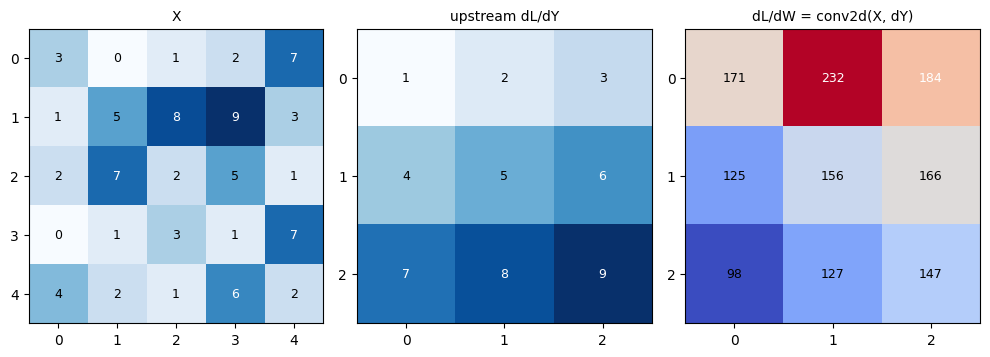

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
show_grid(axes[0], X, "X", cmap="Blues")
show_grid(axes[1], dY, "upstream dL/dY", cmap="Blues")
show_grid(axes[2], dW, "dL/dW = conv2d(X, dY)", cmap="coolwarm")
plt.tight_layout(); plt.show()

## 5. Input gradient $\partial L/\partial X$

Input pixel $X[i',j']$ affects only the outputs in its region $P$, so
$$\frac{\partial L}{\partial X[i',j']}=\sum_{p\in P}
  \frac{\partial L}{\partial Y[p]}\,\frac{\partial Y[p]}{\partial X[i',j']}
  =\sum_{a}\sum_{b}\frac{\partial L}{\partial Y[i'-a,\,j'-b]}\,W[a,b],$$
using $\partial Y[p]/\partial X[i',j']=W[a,b]$ (each output is linear in the
input, with the weight as coefficient). Terms whose $Y$ index falls outside
the valid range count as zero.

In code this is a **full** cross-correlation of the zero-padded upstream gradient
with the 180-degree flipped filter:
$$\frac{\partial L}{\partial X}
  =\texttt{conv2d}\big(\text{pad}(\partial L/\partial Y,\,K-1),\ \text{flip180}(W)\big).$$
This is the lecture punchline: backprop to the input FLIPS the filter. The
slide writes it $\partial L/\partial X=\partial L/\partial Y * \text{flip180}(W)$.
We verify two ways (the loop sum and the flipped-filter conv) against autograd.

In [8]:
# From scratch. Input pixel X[p,q] feeds output Y[i,j] when i+a=p, j+b=q, so
#   dX[p,q] = sum_{a,b} dY[p-a, q-b] * W[a,b]   (dY is 0 outside its range).
def dX_scratch(dY, W, N1, N2):
    K1, K2 = W.shape
    M1, M2 = dY.shape
    dX = torch.zeros(N1, N2)
    for p in range(N1):
        for q in range(N2):
            s = 0.0
            for a in range(K1):
                for b in range(K2):
                    i, j = p - a, q - b
                    if 0 <= i < M1 and 0 <= j < M2:
                        s += dY[i, j] * W[a, b]
            dX[p, q] = s
    return dX

dX = dX_scratch(dY, W, N1, N2)

# Realize as a full cross-correlation of dY with flip180(W): pad dY by K-1,
# then correlate with the flipped filter.
dX_conv = F.conv2d(dY[None, None], flip180(W)[None, None], padding=K1 - 1)[0, 0]

# Autograd check: X is the leaf this time.
Xg = X.clone().requires_grad_(True)
Yg2 = F.conv2d(Xg[None, None], W[None, None])[0, 0]
Yg2.backward(dY)

print("dL/dX (from scratch region-P sum):\n", dX)
print("dL/dX (full corr of dY with flip180(W)):\n", dX_conv)
print("X.grad (autograd):\n", Xg.grad)
assert torch.allclose(dX, dX_conv), "scratch dX must equal the flipped-filter conv"
assert torch.allclose(dX, Xg.grad), "scratch dX must equal autograd X.grad"
print("OK: dL/dX matches the flipped-filter conv AND autograd")

dL/dX (from scratch region-P sum):
 tensor([[  1.,   2.,   2.,  -2.,  -3.],
        [  5.,   7.,   4.,  -7.,  -9.],
        [ 12.,  15.,   6., -15., -18.],
        [ 11.,  13.,   4., -13., -15.],
        [  7.,   8.,   2.,  -8.,  -9.]])
dL/dX (full corr of dY with flip180(W)):
 tensor([[  1.,   2.,   2.,  -2.,  -3.],
        [  5.,   7.,   4.,  -7.,  -9.],
        [ 12.,  15.,   6., -15., -18.],
        [ 11.,  13.,   4., -13., -15.],
        [  7.,   8.,   2.,  -8.,  -9.]])
X.grad (autograd):
 tensor([[  1.,   2.,   2.,  -2.,  -3.],
        [  5.,   7.,   4.,  -7.,  -9.],
        [ 12.,  15.,   6., -15., -18.],
        [ 11.,  13.,   4., -13., -15.],
        [  7.,   8.,   2.,  -8.,  -9.]])
OK: dL/dX matches the flipped-filter conv AND autograd


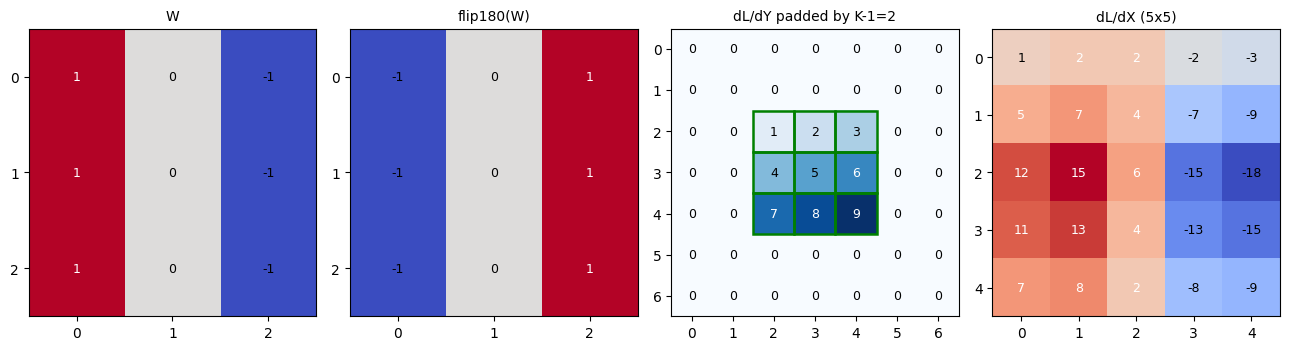

In [9]:
# Visualize the filter flip and the "full convolution" zero-padding.
W_flipped = flip180(W)
dY_padded = F.pad(dY[None, None], (K2 - 1, K2 - 1, K1 - 1, K1 - 1))[0, 0]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.3))
show_grid(axes[0], W, "W", cmap="coolwarm")
show_grid(axes[1], W_flipped, "flip180(W)", cmap="coolwarm")
show_grid(axes[2], dY_padded, "dL/dY padded by K-1=%d" % (K1 - 1), cmap="Blues")
# outline the original dL/dY sitting inside the zero padding (in green)
for (r, c) in [(K1 - 1 + i, K2 - 1 + j) for i in range(M1) for j in range(M2)]:
    axes[2].add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False,
                                    edgecolor="green", lw=1.8))
show_grid(axes[3], dX, "dL/dX (5x5)", cmap="coolwarm")
plt.tight_layout(); plt.show()

In [10]:
# WIDGET 2: gradient explorer. Change the upstream dL/dY and watch dW and dX.
def show_gradients(dy_pattern="ramp", scale=1.0, hot=4):
    if dy_pattern == "ones":
        dYw = torch.ones(M1, M2)
    elif dy_pattern == "ramp":
        dYw = torch.arange(1., M1 * M2 + 1.).reshape(M1, M2)
    else:  # single hot pixel
        dYw = torch.zeros(M1, M2)
        dYw.view(-1)[hot] = 1.0
    dYw = dYw * scale
    dWw = F.conv2d(X[None, None], dYw[None, None])[0, 0]
    dXw = F.conv2d(dYw[None, None], flip180(W)[None, None], padding=K1 - 1)[0, 0]
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
    show_grid(axes[0], dYw, "upstream dL/dY", cmap="Blues", fmt="{:.1f}")
    show_grid(axes[1], dWw, "dL/dW", cmap="coolwarm", fmt="{:.1f}")
    show_grid(axes[2], dXw, "dL/dX", cmap="coolwarm", fmt="{:.1f}")
    plt.tight_layout(); plt.show()

interact(show_gradients,
         dy_pattern=Dropdown(options=["ones", "ramp", "single hot pixel"],
                             value="ramp"),
         scale=FloatSlider(min=0.5, max=3.0, step=0.5, value=1.0),
         hot=IntSlider(min=0, max=M1 * M2 - 1, value=4, description="hot idx"));

interactive(children=(Dropdown(description='dy_pattern', index=1, options=('ones', 'ramp', 'single hot pixel')…

## 6. Backprop through pooling

Pooling layers have no weights, they only ROUTE gradients:
- MAX pooling: in the forward pass record the argmax (winning pixel) of each
  block. In backward, the whole upstream gradient of a block goes to that one
  winner; every other pixel in the block gets $0$.
- AVERAGE pooling: each output is the mean of its $K\times K$ block, so the
  upstream gradient is split EQUALLY, each pixel receiving
  $\dfrac{1}{K\cdot K}$ of it.

We implement both, visualize the routing, and check against autograd. We use a
non-overlapping block of size $K$ (stride $K$), matching `F.max_pool2d` and
`F.avg_pool2d` defaults.

In [11]:
# Distinct integer values (a shuffled 0..15) so every 2x2 block has a unique
# maximum: no ties, so our argmax matches F.max_pool2d exactly.
Xp = torch.randperm(16).reshape(4, 4).float()
Kp = 2

def maxpool_forward(Xp, Kp):
    H, Wd = Xp.shape
    OH, OW = H // Kp, Wd // Kp
    out = torch.zeros(OH, OW)
    winners = {}                       # (oi,oj) -> (row,col) of the max in Xp
    for oi in range(OH):
        for oj in range(OW):
            block = Xp[oi * Kp:(oi + 1) * Kp, oj * Kp:(oj + 1) * Kp]
            idx = int(torch.argmax(block))
            r = oi * Kp + idx // Kp
            c = oj * Kp + idx % Kp
            out[oi, oj] = Xp[r, c]
            winners[(oi, oj)] = (r, c)
    return out, winners

def maxpool_backward(dY, winners, H, Wd):
    dX = torch.zeros(H, Wd)
    for (oi, oj), (r, c) in winners.items():
        dX[r, c] += dY[oi, oj]         # whole gradient to the winner
    return dX

Yp, winners = maxpool_forward(Xp, Kp)
dYp = torch.tensor([[1., 2.], [3., 4.]])          # made-up upstream gradient
dXp = maxpool_backward(dYp, winners, *Xp.shape)

# Autograd check.
Xpg = Xp.clone().requires_grad_(True)
Ypg = F.max_pool2d(Xpg[None, None], Kp)[0, 0]
Ypg.backward(dYp)

print("Xp:\n", Xp)
print("max-pool output:\n", Yp)
print("winners (out cell -> input row,col):", winners)
print("dL/dX (scratch routing):\n", dXp)
print("X.grad (autograd):\n", Xpg.grad)
assert torch.allclose(Yp, Ypg.detach()), "max-pool forward mismatch"
assert torch.allclose(dXp, Xpg.grad), "max-pool backward routing mismatch"
print("OK: max-pool forward and backward match autograd")

Xp:
 tensor([[12., 10.,  9.,  6.],
        [11.,  8., 13.,  5.],
        [ 2., 14., 15.,  0.],
        [ 4.,  3.,  7.,  1.]])
max-pool output:
 tensor([[12., 13.],
        [14., 15.]])
winners (out cell -> input row,col): {(0, 0): (0, 0), (0, 1): (1, 2), (1, 0): (2, 1), (1, 1): (2, 2)}
dL/dX (scratch routing):
 tensor([[1., 0., 0., 0.],
        [0., 0., 2., 0.],
        [0., 3., 4., 0.],
        [0., 0., 0., 0.]])
X.grad (autograd):
 tensor([[1., 0., 0., 0.],
        [0., 0., 2., 0.],
        [0., 3., 4., 0.],
        [0., 0., 0., 0.]])
OK: max-pool forward and backward match autograd


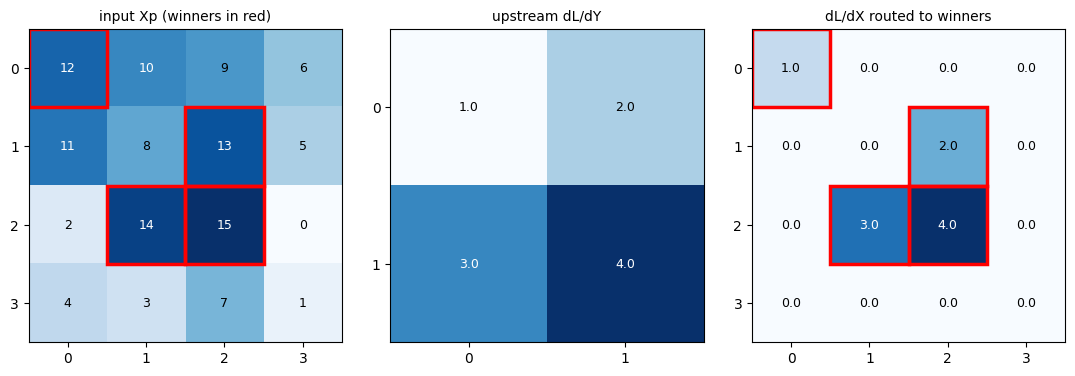

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
show_grid(axes[0], Xp, "input Xp (winners in red)", highlight=set(winners.values()))
show_grid(axes[1], dYp, "upstream dL/dY", fmt="{:.1f}")
show_grid(axes[2], dXp, "dL/dX routed to winners", fmt="{:.1f}",
          highlight=set(winners.values()))
plt.tight_layout(); plt.show()

In [13]:
# Average pooling: forward is the block mean, backward spreads by 1/(K*K).
def avgpool_forward(Xp, Kp):
    H, Wd = Xp.shape
    OH, OW = H // Kp, Wd // Kp
    out = torch.zeros(OH, OW)
    for oi in range(OH):
        for oj in range(OW):
            out[oi, oj] = Xp[oi * Kp:(oi + 1) * Kp, oj * Kp:(oj + 1) * Kp].mean()
    return out

def avgpool_backward(dY, Kp, H, Wd):
    dX = torch.zeros(H, Wd)
    for oi in range(dY.shape[0]):
        for oj in range(dY.shape[1]):
            dX[oi * Kp:(oi + 1) * Kp, oj * Kp:(oj + 1) * Kp] = dY[oi, oj] / (Kp * Kp)
    return dX

Ya = avgpool_forward(Xp, Kp)
dXa = avgpool_backward(dYp, Kp, *Xp.shape)

Xag = Xp.clone().requires_grad_(True)
Yag = F.avg_pool2d(Xag[None, None], Kp)[0, 0]
Yag.backward(dYp)

print("avg-pool output:\n", Ya)
print("dL/dX (scratch, each pixel = dY / (K*K)):\n", dXa)
print("X.grad (autograd):\n", Xag.grad)
assert torch.allclose(Ya, Yag.detach()), "avg-pool forward mismatch"
assert torch.allclose(dXa, Xag.grad), "avg-pool backward mismatch"
print("OK: average-pool forward and backward match autograd")

avg-pool output:
 tensor([[10.2500,  8.2500],
        [ 5.7500,  5.7500]])
dL/dX (scratch, each pixel = dY / (K*K)):
 tensor([[0.2500, 0.2500, 0.5000, 0.5000],
        [0.2500, 0.2500, 0.5000, 0.5000],
        [0.7500, 0.7500, 1.0000, 1.0000],
        [0.7500, 0.7500, 1.0000, 1.0000]])
X.grad (autograd):
 tensor([[0.2500, 0.2500, 0.5000, 0.5000],
        [0.2500, 0.2500, 0.5000, 0.5000],
        [0.7500, 0.7500, 1.0000, 1.0000],
        [0.7500, 0.7500, 1.0000, 1.0000]])
OK: average-pool forward and backward match autograd


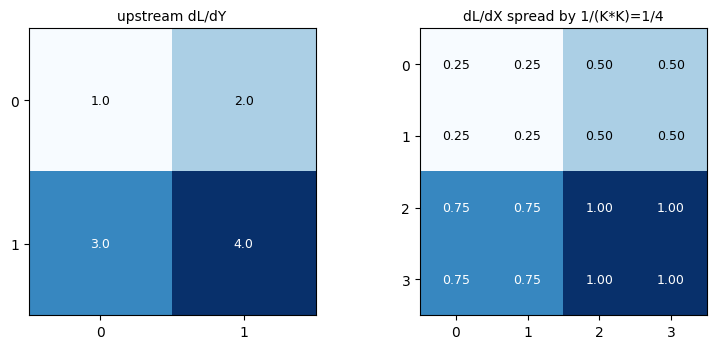

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
show_grid(axes[0], dYp, "upstream dL/dY", fmt="{:.1f}")
show_grid(axes[1], dXa, "dL/dX spread by 1/(K*K)=1/4", fmt="{:.2f}")
plt.tight_layout(); plt.show()

In [15]:
# WIDGET 3: pooling routing. Pick the pool type and a single hot upstream cell.
n_out = (Xp.shape[0] // Kp)
def show_pool_routing(pool="max", hot_cell=0, value=4.0):
    dYw = torch.zeros(n_out, n_out)
    dYw.view(-1)[hot_cell] = value
    if pool == "max":
        dXw = maxpool_backward(dYw, winners, *Xp.shape)
        hl = set(winners.values())
        right_title = "dL/dX routed to winner(s)"
    else:
        dXw = avgpool_backward(dYw, Kp, *Xp.shape)
        hl = set()
        right_title = "dL/dX spread by 1/(K*K)"
    fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
    show_grid(axes[0], dYw, "upstream dL/dY (cell %d = %.1f)" % (hot_cell, value),
              fmt="{:.1f}")
    show_grid(axes[1], dXw, right_title, fmt="{:.2f}", highlight=hl)
    plt.tight_layout(); plt.show()

interact(show_pool_routing,
         pool=Dropdown(options=["max", "average"], value="max"),
         hot_cell=IntSlider(min=0, max=n_out * n_out - 1, value=0,
                            description="hot out cell"),
         value=FloatSlider(min=1.0, max=8.0, step=1.0, value=4.0));

interactive(children=(Dropdown(description='pool', options=('max', 'average'), value='max'), IntSlider(value=0…

## 7. Capstone: one full backward pass end to end

Put it together in a tiny pipeline
$$X \;\xrightarrow{\text{conv } W}\; Y_1 \;\xrightarrow{\text{max-pool}}\; Y_2
  \;\xrightarrow{\text{MSE}}\; L.$$
We run ONE manual backward pass from scratch: the MSE gradient, then max-pool
routing, then the conv weight and input gradients, and we match every step to
`torch.autograd`. For the mean-squared-error loss over $n$ elements,
$\dfrac{\partial L}{\partial Y_2}=\dfrac{2}{n}\,(Y_2-T)$.

In [16]:
torch.manual_seed(2)
Xc = torch.randn(6, 6)                 # continuous, so pooling has no ties
Wc = torch.randn(3, 3)
T  = torch.randn(2, 2)                 # regression target

# ---- Forward (from scratch) ----
Y1 = conv2d_scratch(Xc, Wc)            # 6x6 conv 3x3 -> 4x4
Y2, wins_c = maxpool_forward(Y1, 2)    # 4x4 max-pool 2 -> 2x2
L = ((Y2 - T) ** 2).mean()            # scalar MSE loss

# ---- Manual backward (from scratch) ----
n = Y2.numel()
dY2 = 2.0 * (Y2 - T) / n               # dL/dY2 for the mean-squared error
dY1 = maxpool_backward(dY2, wins_c, *Y1.shape)                 # through max-pool
dWc = F.conv2d(Xc[None, None], dY1[None, None])[0, 0]          # dL/dW
dXc = F.conv2d(dY1[None, None], flip180(Wc)[None, None], padding=2)[0, 0]  # dL/dX

# ---- Autograd end to end ----
Xca = Xc.clone().requires_grad_(True)
Wca = Wc.clone().requires_grad_(True)
Y1a = F.conv2d(Xca[None, None], Wca[None, None])[0, 0]
Y2a = F.max_pool2d(Y1a[None, None], 2)[0, 0]
La = ((Y2a - T) ** 2).mean()
La.backward()

print("loss (scratch):", float(L), "  loss (autograd):", float(La))
assert torch.allclose(L, La), "loss mismatch"
assert torch.allclose(dWc, Wca.grad, atol=1e-5), "manual dL/dW must match autograd"
assert torch.allclose(dXc, Xca.grad, atol=1e-5), "manual dL/dX must match autograd"
print("OK: full manual backward (MSE -> max-pool -> conv) matches autograd end to end")

loss (scratch): 3.117704153060913   loss (autograd): 3.117704153060913
OK: full manual backward (MSE -> max-pool -> conv) matches autograd end to end


/var/folders/j0/z7mrqrv9121_0pm8njw3pbxh0000gp/T/ipykernel_14801/1700505342.py:26: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("loss (scratch):", float(L), "  loss (autograd):", float(La))


## Key takeaways

- Forward conv (our convention) is $Y[i,j]=\sum_{a,b}X[i+a,j+b]W[a,b]$, which is
  exactly `F.conv2d`.
- WEIGHT gradient is a convolution of the input with the upstream gradient:
  $\partial L/\partial W=\texttt{conv2d}(X,\ \partial L/\partial Y)$. One weight
  collects gradient from EVERY output pixel.
- The input gradient is a **full** convolution of the upstream gradient with the
  FLIPPED filter:
  $\partial L/\partial X=\texttt{conv2d}(\text{pad}(\partial L/\partial Y,K-1),\ \text{flip180}(W))$.
  One input pixel collects gradient only from its region $P$.
- MAX pooling routes the whole gradient to the winning pixel (the argmax saved
  in the forward pass); every other pixel gets $0$.
- AVERAGE pooling splits the gradient equally, $1/(K\cdot K)$ to each pixel in
  the block.
- Every hand-derived result matched `torch.autograd` through `torch.allclose`.
  That agreement is the proof our math is right.

## Exercises
- Change $W$ to a horizontal-edge or a blur filter and watch $\partial L/\partial X$.
- Set the upstream gradient to a single hot pixel and see which weights and
  which inputs receive gradient.
- Make the pooling block $3\times 3$ (use a $6\times 6$ input) and recheck the
  routing.
- Add a bias to the conv and derive $\partial L/\partial b$ (hint: it is just
  the sum of the upstream gradient).
- Swap MSE for a different loss in the capstone and confirm autograd still
  matches your manual $\partial L/\partial Y_2$.